# DysCalc ML Validation Pipeline — Leakage-Free Master Notebook

This notebook is the **main validator-facing pipeline** for the DysCalc machine-learning component. It consolidates and improves the original notebooks:

- `dataset_analysis.ipynb` — exploratory analysis and cleaning logic
- `synthetic_data_generation.ipynb` — GAN-based minority augmentation
- `tstr_vs_trtr_no_thresholding.ipynb` — TRTR vs real+synthetic model comparison
- `tstr_vs_trtr.ipynb` — thresholding experiments, retained as supporting material only

The main correction in this version is methodological: **the data is split before any fitted preprocessing or synthetic-data training is performed**. All fitted preprocessing statistics, clipping limits, GAN fitting, and synthetic augmentation are derived from the training set only. Validation and test sets remain fully real and are used only for model selection and final evaluation.

## 0. Methodological Guardrails

This notebook is organized to match the ML expert validation form:

1. Data loading and feature definitions
2. Label audit and screening-target framing
3. Train/validation/test split before fitted preprocessing
4. Training-only preprocessing and feature engineering
5. TRTR baseline model
6. GAN-based synthetic At-Risk training augmentation
7. Statistical validation of synthetic samples
8. TRSTR model evaluation
9. Final TRTR vs TRSTR comparison and validator checklist

Terminology:

- **TRTR**: Train on real training data, test on real validation/test data.
- **TRSTR**: Train on real + synthetic training data, test on real validation/test data.

The system is framed only as an **early screening support tool**, not a clinical diagnostic system.

## 1. Imports and Configuration

This section keeps the original feature definitions but prepares a cleaner, reproducible pipeline.

In [1]:
import os
import sys
import json
import random
import time
import warnings
from pathlib import Path
from itertools import product
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    fbeta_score, f1_score, recall_score, precision_score,
    accuracy_score, roc_auc_score, mean_squared_error,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path.cwd()
ROOT_DIR = BASE_DIR.parent if (BASE_DIR.parent / "datasets").exists() else BASE_DIR
DATASETS_DIR = ROOT_DIR / "datasets" / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs" / "logs_and_metrics"
MODEL_OUTPUTS_DIR = ROOT_DIR / "outputs" / "model_results"
SYNTH_OUTPUTS_DIR = ROOT_DIR / "outputs" / "synthetic_validation"

for d in [DATASETS_DIR, OUTPUTS_DIR, MODEL_OUTPUTS_DIR, SYNTH_OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_FEATURES = ["NC", "DM", "NS", "ADD", "SUB", "CA"]
DERIVED_FEATURES = ["NP", "SN", "AF", "BC", "AS", "PF"]
INCOMPLETE_FLAGS = [f"{c}_incomplete" for c in RAW_FEATURES]
DIAGNOSTIC_FEATURES = RAW_FEATURES + DERIVED_FEATURES + INCOMPLETE_FLAGS
LABEL_COL = "Label"

FUNA_DB_DOMAIN_MAPPING: Dict[str, str] = {
    "NC":  "Number Comparison",
    "DM":  "Digit-Dot Matching",
    "NP":  "Overall Processing Efficiency",
    "SN":  "Symbolic vs. Non-Symbolic Processing Difference",
    "NS":  "Number Series",
    "ADD": "Single-Digit Addition",
    "SUB": "Single-Digit Subtraction",
    "CA":  "Multi-Digit Addition and Subtraction",
    "AF":  "Overall Arithmetic Fluency",
    "BC":  "Basic vs. Complex Arithmetic Contrast",
    "AS":  "Addition vs. Subtraction Asymmetry",
    "PF":  "Processing-Fluency Integration",
    **{f"{c}_incomplete": f"{c} Missing/Incomplete Indicator" for c in RAW_FEATURES},
}

print("Configuration loaded.")
print("DATASETS_DIR:", DATASETS_DIR)
print("OUTPUTS_DIR:", OUTPUTS_DIR)

Configuration loaded.
DATASETS_DIR: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/datasets/processed
OUTPUTS_DIR: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/outputs/logs_and_metrics


## 2. Load Dataset

Expected input file: `datasets/processed/FUNADB_labled.csv`.

The original notebooks used `FUNADB_labled.csv` as the starting dataset. This master notebook continues to use that file, but it treats it as the **raw labeled analysis file** and performs leakage-controlled splitting and preprocessing afterward.

In [2]:
DATA_FILE = DATASETS_DIR / "FUNADB_labled.csv"
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Place FUNADB_labled.csv under datasets/processed/."
    )

df_raw = pd.read_csv(DATA_FILE)

required_cols = RAW_FEATURES + [LABEL_COL]
missing_required = [c for c in required_cols if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Keep only required modeling columns plus any externally documented label-source columns if present.
df_raw = df_raw.copy()

print("Raw dataset shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
print("\nLabel distribution:")
print(df_raw[LABEL_COL].value_counts(dropna=False).sort_index())

display(df_raw.head())

Raw dataset shape: (358, 7)
Columns: ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'Label']

Label distribution:
Label
0    220
1    138
Name: count, dtype: int64


,NC,DM,NS,ADD,SUB,CA,Label
0,1248.000000,2903.384615,5,23,17,8,1
1,921.142857,2212.000000,21,48,22,29,0
2,902.720000,1943.846154,14,28,26,18,1
3,1334.297872,3707.268293,9,17,10,-99,1
4,1274.509804,2384.918919,16,34,37,16,0


## 3. Label Construction Audit and Screening Framing

The label must be created from an external arithmetic fluency reference, such as RMAT, and the reference variable must **not** be used as a predictive feature.

Because this notebook starts from `FUNADB_labled.csv`, this section documents and audits the label column. If the repository contains the raw RMAT/reference score column, add the exact threshold rule in the marked cell below. If the label has already been constructed before export, retain the audit and clearly state the construction rule in markdown.

In [3]:
print("Label values:", sorted(df_raw[LABEL_COL].dropna().unique()))
print("Label dtype:", df_raw[LABEL_COL].dtype)

# Standardize labels to 0/1 if needed.
label_map = {
    "Typical": 0,
    "Not At-Risk": 0,
    "Not At Risk": 0,
    "At-Risk": 1,
    "At Risk": 1,
    "at-risk": 1,
    "typical": 0,
}
if not set(df_raw[LABEL_COL].dropna().unique()).issubset({0, 1}):
    df_raw[LABEL_COL] = df_raw[LABEL_COL].map(label_map)

if df_raw[LABEL_COL].isna().any():
    raise ValueError("Label contains unmapped or missing values after standardization.")

df_raw[LABEL_COL] = df_raw[LABEL_COL].astype(int)

# Audit leakage: known reference/label-source variables must not be in model features.
possible_reference_cols = [
    c for c in df_raw.columns
    if any(token in c.lower() for token in ["rmat", "reference", "fluency", "criterion", "diagnosis"])
]

print("Possible label-source/reference columns found:", possible_reference_cols)
print("Model raw features:", RAW_FEATURES)
print("Reference columns used as model features?", sorted(set(possible_reference_cols) & set(RAW_FEATURES)))
print("\nFinal standardized label distribution:")
print(df_raw[LABEL_COL].value_counts().rename({0: "Typical (0)", 1: "At-Risk (1)"}))

Label values: [0, 1]
Label dtype: int64
Possible label-source/reference columns found: []
Model raw features: ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
Reference columns used as model features? []

Final standardized label distribution:
Label
Typical (0)    220
At-Risk (1)    138
Name: count, dtype: int64


> **Label-construction note for the manuscript/validator:**  
> The binary target represents a screening label: `0 = Typical`, `1 = At-Risk`. The At-Risk label should be derived from an external arithmetic fluency reference such as RMAT. The external reference is used only to construct the target and is excluded from the predictive feature set. The classifier therefore predicts screening status from FUNA-DB numeracy task features, not from the label-source variable itself.

## 4. Split Before Fitted Preprocessing

This is the key improvement over the original workflow. Splitting happens before median imputation, IQR clipping, synthetic-data training, or model fitting.

In [4]:
model_input_raw = df_raw[RAW_FEATURES + [LABEL_COL]].copy()

train_raw, temp_raw = train_test_split(
    model_input_raw,
    test_size=0.30,
    stratify=model_input_raw[LABEL_COL],
    random_state=SEED,
)

val_raw, test_raw = train_test_split(
    temp_raw,
    test_size=0.50,
    stratify=temp_raw[LABEL_COL],
    random_state=SEED,
)

print("Split sizes:")
for name, split in [("train_raw", train_raw), ("val_raw", val_raw), ("test_raw", test_raw)]:
    print(f"{name:<10} shape={split.shape}, distribution={split[LABEL_COL].value_counts().sort_index().to_dict()}")

Split sizes:
train_raw  shape=(250, 7), distribution={0: 154, 1: 96}
val_raw    shape=(54, 7), distribution={0: 33, 1: 21}
test_raw   shape=(54, 7), distribution={0: 33, 1: 21}


## 5. Training-Only Preprocessing and Feature Engineering

The preprocessing object below is fitted only on `train_raw`. It stores:

- invalid/sentinel replacement rules,
- training medians for imputation,
- training IQR clipping limits,
- missingness indicator logic,
- deterministic derived-feature formulas.

No validation or test statistics are used to fit preprocessing parameters.

In [5]:
SENTINEL_VALUES = [-999, -99, 999, 9999, "", " ", "NA", "N/A", "nan", "NaN", None]

class LeakageFreeFunaPreprocessor:
    """Fit preprocessing parameters on training data only, then apply to any split."""

    def __init__(self, raw_features: List[str], clip_quantiles: Tuple[float, float] = (0.25, 0.75)):
        self.raw_features = raw_features
        self.clip_quantiles = clip_quantiles
        self.medians_: Dict[str, float] = {}
        self.clip_bounds_: Dict[str, Tuple[float, float]] = {}
        self.fitted_ = False

    def _numericize(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out[self.raw_features] = out[self.raw_features].replace(SENTINEL_VALUES, np.nan)
        for col in self.raw_features:
            out[col] = pd.to_numeric(out[col], errors="coerce")
        return out

    def fit(self, df_train: pd.DataFrame):
        train = self._numericize(df_train)
        self.medians_ = train[self.raw_features].median(numeric_only=True).to_dict()

        # Fallback if any median is missing.
        for col in self.raw_features:
            if pd.isna(self.medians_.get(col)):
                self.medians_[col] = 0.0

        filled = train[self.raw_features].fillna(self.medians_)
        for col in self.raw_features:
            q1 = filled[col].quantile(0.25)
            q3 = filled[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            self.clip_bounds_[col] = (float(lower), float(upper))

        self.fitted_ = True
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self.fitted_:
            raise RuntimeError("Preprocessor must be fitted before transform().")

        out = self._numericize(df)

        # Missingness flags are created before imputation to preserve incomplete-response signal.
        for col in self.raw_features:
            out[f"{col}_incomplete"] = out[col].isna().astype(int)

        # Apply training-only imputation and clipping.
        out[self.raw_features] = out[self.raw_features].fillna(self.medians_)
        for col in self.raw_features:
            lower, upper = self.clip_bounds_[col]
            out[col] = out[col].clip(lower, upper)

        out = compute_derived_features(out)
        keep_cols = self.raw_features + DERIVED_FEATURES + INCOMPLETE_FLAGS + [LABEL_COL]
        return out[keep_cols].copy()


def compute_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute all derived features deterministically from raw FUNA-DB task features."""
    out = df.copy()
    out["NP"] = (out["NC"] + out["DM"]) / 2
    out["SN"] = out["NS"] - out["NC"]
    out["AF"] = (out["ADD"] + out["SUB"] + out["CA"]) / 3
    out["BC"] = (out["ADD"] + out["SUB"]) / 2 - out["CA"]
    out["AS"] = out["ADD"] - out["SUB"]
    out["PF"] = out["NP"] - out["AF"]
    return out

preprocessor = LeakageFreeFunaPreprocessor(RAW_FEATURES)
preprocessor.fit(train_raw)

train_df = preprocessor.transform(train_raw)
val_df = preprocessor.transform(val_raw)
test_df = preprocessor.transform(test_raw)

print("Training medians used for all splits:")
print(pd.Series(preprocessor.medians_))
print("\nTraining IQR clipping bounds used for all splits:")
print(pd.DataFrame(preprocessor.clip_bounds_, index=["lower", "upper"]).T)

print("\nProcessed split shapes:")
for name, split in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
    print(f"{name:<9} {split.shape}, distribution={split[LABEL_COL].value_counts().sort_index().to_dict()}")

Training medians used for all splits:
NC      910.541667
DM     1946.341463
NS       15.000000
ADD      40.000000
SUB      35.000000
CA       21.000000
dtype: float64

Training IQR clipping bounds used for all splits:
          lower        upper
NC   157.640714  1739.503571
DM    86.289474  4025.026316
NS    -1.000000    31.000000
ADD    3.000000    75.000000
SUB    0.500000    68.500000
CA    -8.500000    51.500000

Processed split shapes:
train_df  (250, 19), distribution={0: 154, 1: 96}
val_df    (54, 19), distribution={0: 33, 1: 21}
test_df   (54, 19), distribution={0: 33, 1: 21}


## 6. Save Leakage-Free Real Splits

These files replace the earlier split files for validator-facing model evaluation.

In [6]:
train_path = DATASETS_DIR / "train_leakage_free.csv"
val_path = DATASETS_DIR / "val_leakage_free.csv"
test_path = DATASETS_DIR / "test_leakage_free.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved:")
print(train_path)
print(val_path)
print(test_path)

Saved:
/Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/datasets/processed/train_leakage_free.csv
/Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/datasets/processed/val_leakage_free.csv
/Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/datasets/processed/test_leakage_free.csv


## 7. Model Helpers

This section follows the original `tstr_vs_trtr_no_thresholding.ipynb` logic, but uses the leakage-free splits created above.

The notebook first tries to use the repository's custom `C45DecisionTree`. If that class is unavailable in the current environment, it falls back to `sklearn.tree.DecisionTreeClassifier` so the notebook remains executable for review.

In [7]:
try:
    sys.path.append(str(ROOT_DIR))
    from src.C45DecisionTree import C45DecisionTree
    TREE_BACKEND = "custom_c45"
    print("Using custom C45DecisionTree from src.C45DecisionTree")
except Exception as e:
    from sklearn.tree import DecisionTreeClassifier
    C45DecisionTree = None
    TREE_BACKEND = "sklearn_decision_tree"
    print("Custom C45DecisionTree unavailable; using sklearn DecisionTreeClassifier fallback.")
    print("Import error:", repr(e))


def split_xy(df: pd.DataFrame):
    X = df[DIAGNOSTIC_FEATURES].copy()
    y = df[LABEL_COL].astype(int).copy()
    return X, y


def fit_tree(X_train: pd.DataFrame, y_train: pd.Series, params: dict):
    if TREE_BACKEND == "custom_c45":
        tree = C45DecisionTree(**params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        tree.fit(X_train, y_train, raw_features=RAW_FEATURES + INCOMPLETE_FLAGS)
        return tree
    else:
        mapped = {
            "max_depth": params.get("max_depth"),
            "min_samples_leaf": params.get("min_samples_leaf", 1),
            "random_state": SEED,
            "class_weight": None,
        }
        tree = DecisionTreeClassifier(**mapped)
        tree.fit(X_train, y_train)
        return tree


def get_preds(tree, X: pd.DataFrame) -> np.ndarray:
    return np.asarray(tree.predict(X)).astype(int)


def get_probs(tree, X: pd.DataFrame) -> np.ndarray:
    if hasattr(tree, "predict_proba"):
        try:
            if TREE_BACKEND == "custom_c45":
                return np.asarray(tree.predict_proba(X, positive_class=1), dtype=float)
            proba = tree.predict_proba(X)
            if proba.shape[1] == 1:
                return np.repeat(proba[0, 0], len(X))
            return proba[:, 1]
        except TypeError:
            proba = tree.predict_proba(X)
            return proba[:, 1]
    return get_preds(tree, X).astype(float)


def safe_auc(y_true, probs):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, probs)


def compute_metrics(y_true, preds, probs=None) -> dict:
    y_true = np.asarray(y_true).astype(int)
    preds = np.asarray(preds).astype(int)
    out = {
        "recall": recall_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "f2": fbeta_score(y_true, preds, beta=2, zero_division=0),
        "accuracy": accuracy_score(y_true, preds),
    }
    if probs is not None:
        out["auc"] = safe_auc(y_true, probs)
        out["rmse"] = float(np.sqrt(mean_squared_error(y_true, probs)))
    return out


def evaluate_model(name: str, tree, X, y) -> dict:
    preds = get_preds(tree, X)
    probs = get_probs(tree, X)
    metrics = compute_metrics(y, preds, probs)
    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        print(f"  {k:<10}: {v:.4f}")
    print("\nConfusion matrix [rows=true, cols=pred]:")
    print(confusion_matrix(y, preds))
    print("\nClassification report:")
    print(classification_report(y, preds, target_names=["Typical", "At-Risk"], zero_division=0))
    return metrics

Using custom C45DecisionTree from src.C45DecisionTree


## 8. TRTR Baseline: Train Real, Validate/Test Real

Hyperparameters are selected using the fully real validation set. The test set is reserved for final evaluation.

In [8]:
X_train, y_train = split_xy(train_df)
X_val, y_val = split_xy(val_df)
X_test, y_test = split_xy(test_df)

if TREE_BACKEND == "custom_c45":
    PARAM_GRID = {
        "conf_fact": [0.15, 0.25, 0.35],
        "min_samples_leaf": [10, 15, 20, 25, 30],
        "max_depth": [5, 7, 9, 11],
    }
else:
    PARAM_GRID = {
        "min_samples_leaf": [2, 5, 10, 15, 20, 25, 30],
        "max_depth": [2, 3, 4, 5, 6, 7, 8],
    }


def iter_param_grid(param_grid):
    keys = list(param_grid.keys())
    for values in product(*(param_grid[k] for k in keys)):
        yield dict(zip(keys, values))


def validation_grid_search(X_tr, y_tr, X_va, y_va, model_label: str) -> Tuple[dict, pd.DataFrame]:
    rows = []
    all_params = list(iter_param_grid(PARAM_GRID))
    total_candidates = len(all_params)

    print(f"[{model_label}] Starting validation grid search...", flush=True)
    print(f"[{model_label}] Total candidates: {total_candidates}", flush=True)

    start_time = time.time()

    for i, params in enumerate(all_params, 1):
        if i == 1 or i % 10 == 0 or i == total_candidates:
            elapsed = time.time() - start_time
            print(
                f"[{model_label}] Candidate {i}/{total_candidates} "
                f"| elapsed: {elapsed / 60:.2f} min "
                f"| params: {params}",
                flush=True
            )

        tree = fit_tree(X_tr, y_tr, params)
        preds = get_preds(tree, X_va)
        probs = get_probs(tree, X_va)
        m = compute_metrics(y_va, preds, probs)
        rows.append({"candidate": i, **params, **m})

    search_df = pd.DataFrame(rows)

    sort_cols = ["f2", "recall", "precision", "f1", "accuracy"]
    search_df = search_df.sort_values(sort_cols, ascending=False).reset_index(drop=True)

    best_params = {
        k: search_df.loc[0, k].item() if hasattr(search_df.loc[0, k], "item") else search_df.loc[0, k]
        for k in PARAM_GRID.keys()
    }

    if "min_samples_leaf" in best_params:
        best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

    if "max_depth" in best_params:
        best_params["max_depth"] = int(best_params["max_depth"])

    total_time = time.time() - start_time

    out_path = MODEL_OUTPUTS_DIR / f"{model_label.lower()}_validation_grid_search.csv"
    search_df.to_csv(out_path, index=False)

    print(f"\n[{model_label}] Grid search completed in {total_time / 60:.2f} minutes.", flush=True)
    print(f"[{model_label}] Best params: {best_params}", flush=True)
    print(f"[{model_label}] Saved grid search: {out_path}", flush=True)

    display(search_df.head(10))

    return best_params, search_df

BEST_PARAMS_TRTR, trtr_grid = validation_grid_search(X_train, y_train, X_val, y_val, "TRTR")

trtr_model = fit_tree(X_train, y_train, BEST_PARAMS_TRTR)
trtr_val_metrics = evaluate_model("TRTR validation", trtr_model, X_val, y_val)
trtr_test_metrics = evaluate_model("TRTR test", trtr_model, X_test, y_test)

[TRTR] Starting validation grid search...
[TRTR] Total candidates: 60
[TRTR] Candidate 1/60 | elapsed: 0.00 min | params: {'conf_fact': 0.15, 'min_samples_leaf': 10, 'max_depth': 5}
[TRTR] Candidate 10/60 | elapsed: 0.22 min | params: {'conf_fact': 0.15, 'min_samples_leaf': 20, 'max_depth': 7}
[TRTR] Candidate 20/60 | elapsed: 0.42 min | params: {'conf_fact': 0.15, 'min_samples_leaf': 30, 'max_depth': 11}
[TRTR] Candidate 30/60 | elapsed: 0.67 min | params: {'conf_fact': 0.25, 'min_samples_leaf': 20, 'max_depth': 7}
[TRTR] Candidate 40/60 | elapsed: 0.87 min | params: {'conf_fact': 0.25, 'min_samples_leaf': 30, 'max_depth': 11}
[TRTR] Candidate 50/60 | elapsed: 1.12 min | params: {'conf_fact': 0.35, 'min_samples_leaf': 20, 'max_depth': 7}
[TRTR] Candidate 60/60 | elapsed: 1.32 min | params: {'conf_fact': 0.35, 'min_samples_leaf': 30, 'max_depth': 11}

[TRTR] Grid search completed in 1.33 minutes.
[TRTR] Best params: {'conf_fact': 0.15, 'min_samples_leaf': 10, 'max_depth': 7}
[TRTR] Sav

,candidate,conf_fact,min_samples_leaf,max_depth,recall,precision,f1,f2,accuracy,auc,rmse
0,2,0.15,10,7,0.761905,0.666667,0.711111,0.740741,0.759259,0.854978,0.390857
1,10,0.15,20,7,0.761905,0.666667,0.711111,0.740741,0.759259,0.854257,0.383253
2,11,0.15,20,9,0.761905,0.666667,0.711111,0.740741,0.759259,0.854257,0.383253
3,12,0.15,20,11,0.761905,0.666667,0.711111,0.740741,0.759259,0.854257,0.383253
4,22,0.25,10,7,0.761905,0.666667,0.711111,0.740741,0.759259,0.854978,0.390857
5,30,0.25,20,7,0.761905,0.666667,0.711111,0.740741,0.759259,0.854257,0.383253
6,31,0.25,20,9,0.761905,0.666667,0.711111,0.740741,0.759259,0.854257,0.383253
7,32,0.25,20,11,0.761905,0.666667,0.711111,0.740741,0.759259,0.854257,0.383253
8,42,0.35,10,7,0.761905,0.666667,0.711111,0.740741,0.759259,0.854978,0.390857
9,50,0.35,20,7,0.761905,0.666667,0.711111,0.740741,0.759259,0.854257,0.383253



TRTR validation metrics:
  recall    : 0.7619
  precision : 0.6667
  f1        : 0.7111
  f2        : 0.7407
  accuracy  : 0.7593
  auc       : 0.8550
  rmse      : 0.3909

Confusion matrix [rows=true, cols=pred]:
[[25  8]
 [ 5 16]]

Classification report:
              precision    recall  f1-score   support

     Typical       0.83      0.76      0.79        33
     At-Risk       0.67      0.76      0.71        21

    accuracy                           0.76        54
   macro avg       0.75      0.76      0.75        54
weighted avg       0.77      0.76      0.76        54


TRTR test metrics:
  recall    : 0.6667
  precision : 0.6087
  f1        : 0.6364
  f2        : 0.6542
  accuracy  : 0.7037
  auc       : 0.7143
  rmse      : 0.4548

Confusion matrix [rows=true, cols=pred]:
[[24  9]
 [ 7 14]]

Classification report:
              precision    recall  f1-score   support

     Typical       0.77      0.73      0.75        33
     At-Risk       0.61      0.67      0.64        21


## 9. Train-Only GAN-Based Synthetic Data Generation

This section fixes the main issue in the earlier synthetic notebook. The GAN is trained only on **real At-Risk training rows**.

Validation and test rows are not used for GAN fitting, hyperparameter decisions, filtering, or synthetic sample selection.

In [9]:
train_minority = train_raw[train_raw[LABEL_COL] == 1][RAW_FEATURES].copy()
train_majority_n = int((train_df[LABEL_COL] == 0).sum())
train_minority_n = int((train_df[LABEL_COL] == 1).sum())
n_synth_needed = train_majority_n - train_minority_n

print("Real training majority count:", train_majority_n)
print("Real training minority count:", train_minority_n)
print("Synthetic At-Risk rows needed to balance training:", n_synth_needed)

if n_synth_needed <= 0:
    print("No synthetic rows needed; the real training set is already balanced or minority-heavy.")

Real training majority count: 154
Real training minority count: 96
Synthetic At-Risk rows needed to balance training: 58


In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd

# Force CPU / avoid CUDA initialization issues that can make SDV/torch appear frozen.
# IMPORTANT: after changing this cell, restart the kernel before rerunning.
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

def make_empirical_synthetic_at_risk(
    train_minority_raw: pd.DataFrame,
    n_needed: int,
    seed: int = SEED
) -> pd.DataFrame:
    """
    Fast runtime fallback: bootstrap + small Gaussian noise from real At-Risk training rows only.

    This is NOT GAN-based. Use only when CTGAN hangs in the local environment so the rest
    of the leakage-free pipeline can be executed and checked. For final GAN-specific validation,
    use method='ctgan' after fixing the environment.
    """
    rng = np.random.default_rng(seed)

    if n_needed <= 0:
        return pd.DataFrame(columns=RAW_FEATURES + [LABEL_COL])

    base = train_minority_raw[RAW_FEATURES].copy()
    base = base.replace(SENTINEL_VALUES, np.nan)

    for col in RAW_FEATURES:
        base[col] = pd.to_numeric(base[col], errors="coerce")

    medians = base.median(numeric_only=True)
    base = base.fillna(medians)

    sampled = base.sample(n=n_needed, replace=True, random_state=seed).reset_index(drop=True)

    # Add conservative noise based only on training-minority spread.
    for col in RAW_FEATURES:
        sd = float(base[col].std(ddof=0))
        noise_sd = 0.05 * sd if sd > 0 else 0.0
        sampled[col] = sampled[col] + rng.normal(0, noise_sd, size=n_needed)

        lo = base[col].quantile(0.01)
        hi = base[col].quantile(0.99)
        sampled[col] = sampled[col].clip(lo, hi)

    sampled[LABEL_COL] = 1
    return sampled


def make_synthetic_at_risk_with_gans(
    train_minority_raw: pd.DataFrame,
    n_needed: int,
    seed: int = SEED,
    epochs: int = 3,
    method: str = "ctgan",
    n_candidate_pool: int = 500,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Generate At-Risk synthetic raw features from training-minority rows only.

    method='ctgan':
        GAN-based generation using SDV CTGAN, forced to CPU with a very small architecture.
    method='bootstrap':
        Fast empirical fallback for debugging only; not GAN-based.

    The CTGAN configuration intentionally uses:
    - cuda=False
    - pac=1
    - batch_size=16
    - small generator/discriminator dimensions
    - low epochs

    This avoids common notebook hangs caused by CUDA/backend initialization and heavy defaults.
    """

    total_start = time.time()

    print("=" * 80, flush=True)
    print("SYNTHETIC AT-RISK GENERATION STARTED", flush=True)
    print("=" * 80, flush=True)
    print(f"Method: {method}", flush=True)
    print(f"Requested synthetic rows: {n_needed}", flush=True)
    print(f"Epochs: {epochs}", flush=True)
    print(f"Random seed: {seed}", flush=True)

    if n_needed <= 0:
        print("No synthetic rows needed. Returning empty DataFrame.", flush=True)
        return pd.DataFrame(columns=RAW_FEATURES + [LABEL_COL])

    if method.lower() == "bootstrap":
        print("\nUsing empirical bootstrap fallback. This is for debugging, not GAN validation.", flush=True)
        synth = make_empirical_synthetic_at_risk(train_minority_raw, n_needed, seed=seed)
        print(f"Fallback synthetic shape: {synth.shape}", flush=True)
        print(synth.head().to_string(), flush=True)
        print(f"Total runtime: {(time.time() - total_start) / 60:.2f} minutes", flush=True)
        return synth

    print("\n[1/8] Loading SDV CTGAN synthesizer...", flush=True)
    try:
        from sdv.single_table import CTGANSynthesizer
        from sdv.metadata import SingleTableMetadata
        print("SDV loaded successfully.", flush=True)
    except Exception as e:
        raise ImportError(
            "SDV is required for CTGAN generation. Install with `pip install sdv`, "
            "or switch method='bootstrap' for a quick non-GAN pipeline check."
        ) from e

    print("\n[2/8] Preparing real At-Risk training rows only...", flush=True)

    gan_train = train_minority_raw[RAW_FEATURES].copy()
    print(f"Input minority training shape: {gan_train.shape}", flush=True)

    gan_train = gan_train.replace(SENTINEL_VALUES, np.nan)

    for col in RAW_FEATURES:
        gan_train[col] = pd.to_numeric(gan_train[col], errors="coerce")

    print("\nMissing values before GAN median fill:", flush=True)
    print(gan_train.isna().sum().to_string(), flush=True)

    # Fill for GAN stability only; uses training-minority statistics only.
    medians = gan_train.median(numeric_only=True)
    gan_train = gan_train.fillna(medians)

    print("\nMissing values after GAN median fill:", flush=True)
    print(gan_train.isna().sum().to_string(), flush=True)

    print("\nTraining-minority summary after fill:", flush=True)
    print(gan_train.describe().T.round(4).to_string(), flush=True)

    print("\n[3/8] Adding BC derived feature for generation only...", flush=True)
    gan_train["BC"] = (gan_train["ADD"] + gan_train["SUB"]) / 2 - gan_train["CA"]
    print(f"GAN training shape after adding BC: {gan_train.shape}", flush=True)

    print("\n[4/8] Detecting SDV metadata...", flush=True)
    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(gan_train)
    print("Metadata detection completed.", flush=True)

    n_pool = max(n_candidate_pool, n_needed)
    print(f"\nSynthetic candidate pool size: {n_pool}", flush=True)

    common_kwargs = dict(
        metadata=metadata,
        enforce_rounding=False,
        epochs=epochs,
        verbose=verbose,
        embedding_dim=8,
        generator_dim=(16,),
        discriminator_dim=(16,),
        batch_size=16,
        discriminator_steps=1,
        pac=1,
        cuda=False
    )

    np.random.seed(seed)
    random.seed(seed)

    print("\n[5/8] Training ultra-light CPU-only CTGAN...", flush=True)
    print("No internal notebook prints may appear during ctgan.fit().", flush=True)
    print("For epochs=3 and 96 rows, interrupt if it exceeds 10 minutes.", flush=True)

    ctgan_start = time.time()

    ctgan = CTGANSynthesizer(**common_kwargs)
    print("CTGAN object created. Starting ctgan.fit(gan_train)...", flush=True)

    ctgan.fit(gan_train)

    ctgan_train_time = time.time() - ctgan_start
    print("ctgan.fit(gan_train) finished successfully.", flush=True)
    print(f"CTGAN training completed in {ctgan_train_time / 60:.2f} minutes.", flush=True)

    print(f"\n[6/8] Sampling {n_pool} candidate rows from CTGAN...", flush=True)
    sample_start = time.time()
    synth_pool = ctgan.sample(n_pool)
    print(f"Sampling completed in {time.time() - sample_start:.2f} seconds.", flush=True)
    print(f"Synthetic pool shape before cleaning: {synth_pool.shape}", flush=True)
    print(synth_pool.head().to_string(), flush=True)

    print("\n[7/8] Clipping and cleaning synthetic candidate rows...", flush=True)

    clipping_bounds = {}

    for col in RAW_FEATURES:
        lo = gan_train[col].quantile(0.01)
        hi = gan_train[col].quantile(0.99)

        clipping_bounds[col] = (lo, hi)

        synth_pool[col] = pd.to_numeric(synth_pool[col], errors="coerce")
        synth_pool[col] = synth_pool[col].clip(lo, hi)

    print("\nClipping bounds used:", flush=True)
    for col, (lo, hi) in clipping_bounds.items():
        print(f"{col}: lower={lo:.4f}, upper={hi:.4f}", flush=True)

    before_dropna = len(synth_pool)
    synth_pool = synth_pool.dropna(subset=RAW_FEATURES).reset_index(drop=True)
    after_dropna = len(synth_pool)

    print(f"\nRows before dropna: {before_dropna}", flush=True)
    print(f"Rows after dropna: {after_dropna}", flush=True)
    print(f"Rows removed due to missing raw features: {before_dropna - after_dropna}", flush=True)

    if len(synth_pool) < n_needed:
        raise RuntimeError(
            f"Only {len(synth_pool)} synthetic rows survived filtering; need {n_needed}. "
            "Switch method='bootstrap' for a quick pipeline check or increase n_pool."
        )

    print("\nSynthetic pool summary after clipping and cleaning:", flush=True)
    print(synth_pool[RAW_FEATURES].describe().T.round(4).to_string(), flush=True)

    print("\n[8/8] Selecting final synthetic At-Risk rows...", flush=True)

    synth = synth_pool[RAW_FEATURES].sample(
        n=n_needed,
        random_state=seed
    ).reset_index(drop=True)

    synth[LABEL_COL] = 1

    print(f"Selected final synthetic rows: {len(synth)}", flush=True)
    print("\nFinal synthetic sample preview:", flush=True)
    print(synth.head().to_string(), flush=True)

    print("\nSynthetic label distribution:", flush=True)
    print(synth[LABEL_COL].value_counts().to_string(), flush=True)

    total_time = time.time() - total_start

    print("\n" + "=" * 80, flush=True)
    print("SYNTHETIC AT-RISK GENERATION COMPLETED", flush=True)
    print(f"Total runtime: {total_time / 60:.2f} minutes", flush=True)
    print("=" * 80, flush=True)

    return synth


# ---------------------------------------------------------------------
# RUN SYNTHETIC GENERATION
# ---------------------------------------------------------------------

RUN_GAN_GENERATION = True

# Use "ctgan" for final GAN-based validation.
# If CTGAN still hangs in your environment, set this to "bootstrap" only to test the rest of the notebook.
SYNTHETIC_METHOD = "ctgan"

if RUN_GAN_GENERATION and n_synth_needed > 0:
    synthetic_raw = make_synthetic_at_risk_with_gans(
        train_minority_raw=train_minority,
        n_needed=n_synth_needed,
        seed=SEED,
        epochs=3,
        method=SYNTHETIC_METHOD,
        n_candidate_pool=500,
        verbose=True
    )
else:
    print("Synthetic generation skipped.", flush=True)
    synthetic_raw = pd.DataFrame(columns=RAW_FEATURES + [LABEL_COL])

print("\nSynthetic raw shape:", synthetic_raw.shape, flush=True)
print(synthetic_raw.head().to_string(), flush=True)


SYNTHETIC AT-RISK GENERATION STARTED
Method: ctgan
Requested synthetic rows: 58
Epochs: 3
Random seed: 42

[1/8] Loading SDV CTGAN synthesizer...
SDV loaded successfully.

[2/8] Preparing real At-Risk training rows only...
Input minority training shape: (96, 6)

Missing values before GAN median fill:
NC     1
DM     1
NS     5
ADD    3
SUB    3
CA     9

Missing values after GAN median fill:
NC     0
DM     0
NS     0
ADD    0
SUB    0
CA     0

Training-minority summary after fill:
     count       mean       std        min        25%        50%        75%        max
NC    96.0  1105.0374  356.8176   533.2549   823.9050  1053.2766  1334.5953  2399.1373
DM    96.0  2478.7555  905.0461  1065.7500  1852.3128  2332.0500  3032.3104  5217.2195
NS    96.0    11.9167    5.6001     2.0000     8.0000    12.0000    15.2500    27.0000
ADD   96.0    31.1250   13.0781     5.0000    20.7500    30.0000    40.0000    61.0000
SUB   96.0    27.2292   13.1801     2.0000    18.0000    26.0000    36.0000  

Gen. (-0.49) | Discrim. (0.06): 100%|██████████| 3/3 [00:00<00:00, 14.91it/s]

ctgan.fit(gan_train) finished successfully.
CTGAN training completed in 0.04 minutes.

[6/8] Sampling 300 candidate rows from CTGAN...
Sampling completed in 0.07 seconds.
Synthetic pool shape before cleaning: (300, 7)
            NC           DM         NS        ADD        SUB         CA         BC
0   694.421055  2115.357583   3.918203  23.219844  42.937497   2.000000   2.384120
1  1342.986729  1919.493274  16.219722  25.248406   2.000000  41.000000  12.088313
2  1112.317012  2465.673816   9.500020  38.280203  31.406920   9.945447   3.561597
3   682.987927  1065.750000  13.285717  40.974459  26.120046   7.229565  12.570666
4   533.254902  1823.149410   9.379972  35.999101  22.321320   2.911585   8.805376

[7/8] Clipping and cleaning synthetic candidate rows...

Clipping bounds used:
NC: lower=539.6627, upper=1886.0069
DM: lower=1103.9875, upper=5058.5664
NS: lower=2.9500, upper=24.1500
ADD: lower=5.9500, upper=61.0000
SUB: lower=3.9000, upper=57.1500
CA: lower=2.0000, upper=40.0500




Final synthetic sample preview:
            NC           DM         NS        ADD        SUB         CA  Label
0  1726.846406  4793.213252   3.857081  32.677921  13.730346  26.630340      1
1  1335.941869  2151.268141   6.288020  30.896694  13.242454   9.890985      1
2  1202.666018  1103.987500  15.661013  25.318060   3.900000  19.871596      1
3   778.638511  4200.208312  12.180442  36.850927  14.152253  17.309114      1
4   606.889769  1733.468835   3.493500  14.903216   3.900000  21.075557      1

Synthetic label distribution:
Label
1    58

SYNTHETIC AT-RISK GENERATION COMPLETED
Total runtime: 0.11 minutes

Synthetic raw shape: (58, 7)
            NC           DM         NS        ADD        SUB         CA  Label
0  1726.846406  4793.213252   3.857081  32.677921  13.730346  26.630340      1
1  1335.941869  2151.268141   6.288020  30.896694  13.242454   9.890985      1
2  1202.666018  1103.987500  15.661013  25.318060   3.900000  19.871596      1
3   778.638511  4200.208312  12.18

## 10. Apply the Same Training-Fitted Preprocessor to Synthetic Rows

Synthetic records are transformed using the preprocessor fitted on the original real training split. This preserves a single preprocessing contract for real and synthetic training data.

In [11]:
if len(synthetic_raw) > 0:
    synthetic_df = preprocessor.transform(synthetic_raw)
else:
    synthetic_df = pd.DataFrame(columns=train_df.columns)

synth_path = DATASETS_DIR / "s_train_leakage_free.csv"
synthetic_df.to_csv(synth_path, index=False)

train_trstr_df = pd.concat([train_df, synthetic_df], ignore_index=True)
train_trstr_path = DATASETS_DIR / "train_real_plus_synthetic_leakage_free.csv"
train_trstr_df.to_csv(train_trstr_path, index=False)

print("Synthetic processed shape:", synthetic_df.shape)
print("TRSTR training shape:", train_trstr_df.shape)
print("TRSTR class distribution:")
print(train_trstr_df[LABEL_COL].value_counts().sort_index())
print("Saved synthetic training file:", synth_path)
print("Saved combined training file:", train_trstr_path)

Synthetic processed shape: (58, 19)
TRSTR training shape: (308, 19)
TRSTR class distribution:
Label
0    154
1    154
Name: count, dtype: int64
Saved synthetic training file: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/datasets/processed/s_train_leakage_free.csv
Saved combined training file: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/datasets/processed/train_real_plus_synthetic_leakage_free.csv


## 11. Statistical Validation of Synthetic At-Risk Samples

Synthetic data is compared only against **real At-Risk training samples**. The held-out validation and test sets are not used.

Validation metrics:

- Kolmogorov-Smirnov test p-value
- Jensen-Shannon divergence
- differences in mean, standard deviation, median, skewness, and kurtosis

In [12]:
def jsd_continuous(a, b, bins=20):
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    if len(a) == 0 or len(b) == 0:
        return np.nan
    lo = min(a.min(), b.min())
    hi = max(a.max(), b.max())
    if lo == hi:
        return 0.0
    hist_a, bin_edges = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    hist_b, _ = np.histogram(b, bins=bin_edges, density=True)
    hist_a = hist_a + 1e-12
    hist_b = hist_b + 1e-12
    hist_a = hist_a / hist_a.sum()
    hist_b = hist_b / hist_b.sum()
    return float(jensenshannon(hist_a, hist_b) ** 2)


def distribution_validation(real_train_min_df, synth_df, features=RAW_FEATURES):
    rows = []
    for col in features:
        real = real_train_min_df[col].dropna().astype(float)
        synth = synth_df[col].dropna().astype(float)
        ks_stat, ks_p = stats.ks_2samp(real, synth) if len(real) and len(synth) else (np.nan, np.nan)
        rows.append({
            "feature": col,
            "real_mean": real.mean(),
            "synth_mean": synth.mean(),
            "delta_mean": abs(real.mean() - synth.mean()),
            "real_std": real.std(ddof=1),
            "synth_std": synth.std(ddof=1),
            "delta_std": abs(real.std(ddof=1) - synth.std(ddof=1)),
            "real_median": real.median(),
            "synth_median": synth.median(),
            "delta_median": abs(real.median() - synth.median()),
            "real_skew": real.skew(),
            "synth_skew": synth.skew(),
            "delta_skew": abs(real.skew() - synth.skew()),
            "real_kurt": real.kurtosis(),
            "synth_kurt": synth.kurtosis(),
            "delta_kurt": abs(real.kurtosis() - synth.kurtosis()),
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "jsd": jsd_continuous(real, synth),
        })
    return pd.DataFrame(rows)

if len(synthetic_df) > 0:
    real_min_processed = train_df[train_df[LABEL_COL] == 1].copy()
    dist_results = distribution_validation(real_min_processed, synthetic_df, RAW_FEATURES)
    dist_path = SYNTH_OUTPUTS_DIR / "train_only_synthetic_distribution_validation.csv"
    dist_results.to_csv(dist_path, index=False)
    print("Saved synthetic validation results:", dist_path)
    display(dist_results)
else:
    dist_results = pd.DataFrame()
    print("No synthetic rows generated; statistical validation skipped.")

Saved synthetic validation results: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/outputs/synthetic_validation/train_only_synthetic_distribution_validation.csv


,feature,real_mean,synth_mean,delta_mean,real_std,synth_std,delta_std,real_median,synth_median,delta_median,real_skew,synth_skew,delta_skew,real_kurt,synth_kurt,delta_kurt,ks_stat,ks_p,jsd
0,NC,1094.188516,1074.563623,19.624893,332.776106,349.798155,17.022049,1046.638298,1034.318751,12.319547,0.423066,0.484138,0.061072,-0.850221,-0.635081,0.215140,0.084770,0.931481,0.090619
1,DM,2435.419006,2272.752793,162.666213,812.880227,1043.270314,230.390087,2294.191667,2042.425314,251.766353,0.384497,0.492142,0.107645,-0.792422,-1.072408,0.279986,0.248204,0.018645,0.106940
2,NS,12.072917,11.115019,0.957898,5.642405,6.715914,1.073510,12.000000,9.470335,2.529665,0.329228,0.711723,0.382495,-0.490139,-0.519884,0.029745,0.155891,0.303244,0.093044
3,ADD,31.437500,34.200018,2.762518,13.167594,14.528790,1.361197,30.500000,32.827758,2.327758,0.254283,0.140788,0.113495,-0.549682,-0.632382,0.082700,0.135057,0.473451,0.101403
4,SUB,27.510417,27.212040,0.298376,13.247439,18.149563,4.902124,26.500000,27.343177,0.843177,0.253701,0.228912,0.024788,-0.316824,-1.379258,1.062433,0.219468,0.050825,0.144272
5,CA,17.343750,12.355983,4.987767,9.034237,9.461295,0.427059,16.000000,9.784023,6.215977,0.498464,0.553085,0.054621,-0.241556,-0.652694,0.411138,0.319325,0.000867,0.159028


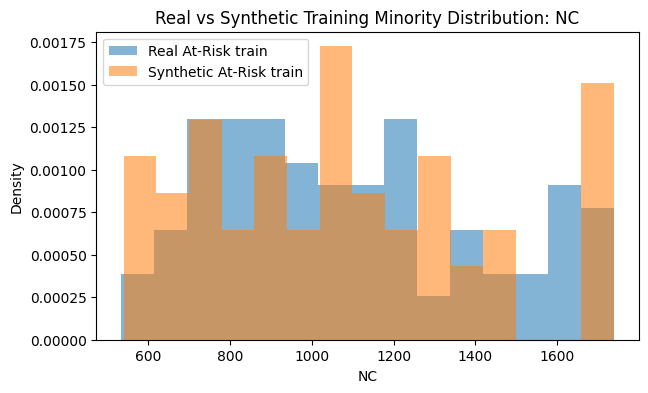

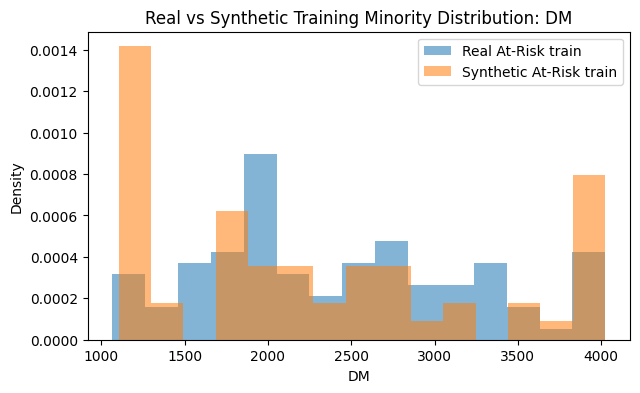

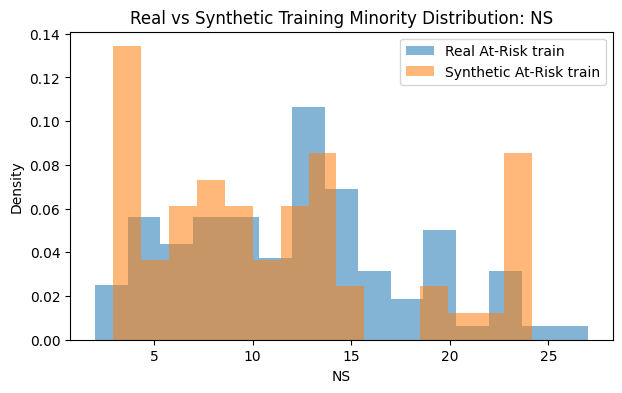

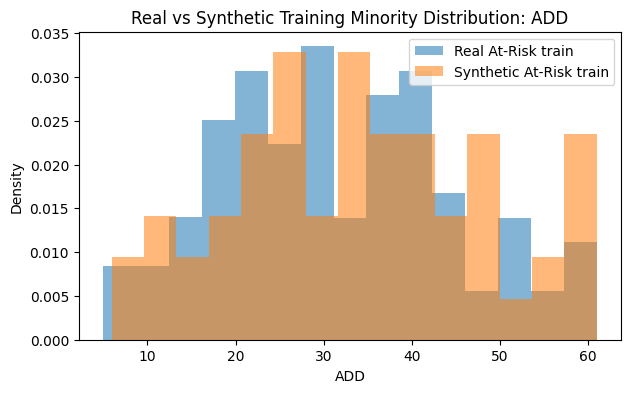

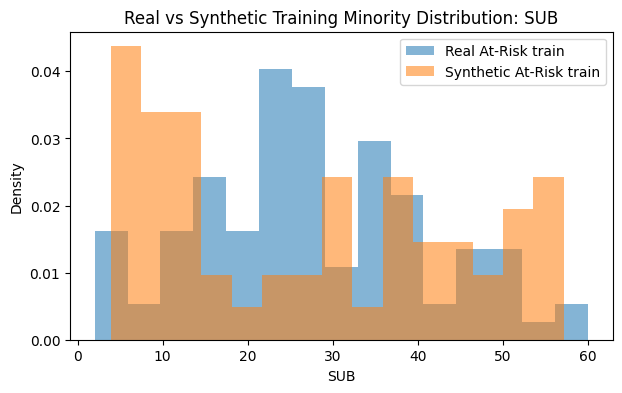

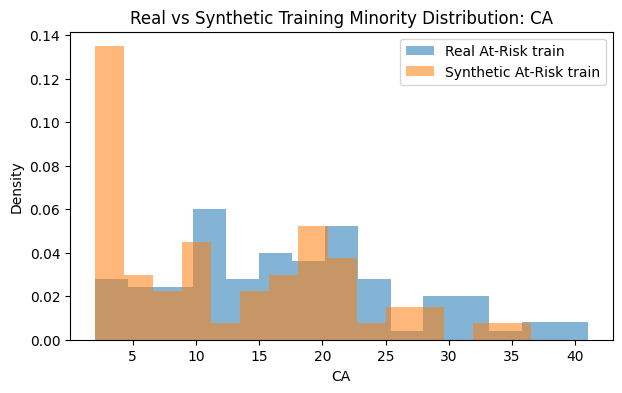

In [13]:
if len(synthetic_df) > 0:
    for col in RAW_FEATURES:
        plt.figure(figsize=(7, 4))
        plt.hist(real_min_processed[col], bins=15, alpha=0.55, density=True, label="Real At-Risk train")
        plt.hist(synthetic_df[col], bins=15, alpha=0.55, density=True, label="Synthetic At-Risk train")
        plt.title(f"Real vs Synthetic Training Minority Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.show()

## 12. TRSTR Model: Train Real + Synthetic, Validate/Test Real

The TRSTR model is trained on the real training set plus synthetic At-Risk training samples only. Validation and test remain fully real.

In [14]:
X_train_trstr, y_train_trstr = split_xy(train_trstr_df)

BEST_PARAMS_TRSTR, trstr_grid = validation_grid_search(X_train_trstr, y_train_trstr, X_val, y_val, "TRSTR")

trstr_model = fit_tree(X_train_trstr, y_train_trstr, BEST_PARAMS_TRSTR)
trstr_val_metrics = evaluate_model("TRSTR validation", trstr_model, X_val, y_val)
trstr_test_metrics = evaluate_model("TRSTR test", trstr_model, X_test, y_test)

[TRSTR] Starting validation grid search...
[TRSTR] Total candidates: 60
[TRSTR] Candidate 1/60 | elapsed: 0.00 min | params: {'conf_fact': 0.15, 'min_samples_leaf': 10, 'max_depth': 5}
[TRSTR] Candidate 10/60 | elapsed: 0.35 min | params: {'conf_fact': 0.15, 'min_samples_leaf': 20, 'max_depth': 7}
[TRSTR] Candidate 20/60 | elapsed: 0.69 min | params: {'conf_fact': 0.15, 'min_samples_leaf': 30, 'max_depth': 11}
[TRSTR] Candidate 30/60 | elapsed: 1.08 min | params: {'conf_fact': 0.25, 'min_samples_leaf': 20, 'max_depth': 7}
[TRSTR] Candidate 40/60 | elapsed: 1.40 min | params: {'conf_fact': 0.25, 'min_samples_leaf': 30, 'max_depth': 11}
[TRSTR] Candidate 50/60 | elapsed: 1.76 min | params: {'conf_fact': 0.35, 'min_samples_leaf': 20, 'max_depth': 7}
[TRSTR] Candidate 60/60 | elapsed: 2.08 min | params: {'conf_fact': 0.35, 'min_samples_leaf': 30, 'max_depth': 11}

[TRSTR] Grid search completed in 2.11 minutes.
[TRSTR] Best params: {'conf_fact': 0.15, 'min_samples_leaf': 10, 'max_depth': 5}

,candidate,conf_fact,min_samples_leaf,max_depth,recall,precision,f1,f2,accuracy,auc,rmse
0,1,0.15,10,5,0.809524,0.73913,0.772727,0.794393,0.814815,0.831169,0.386927
1,9,0.15,20,5,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.381127
2,10,0.15,20,7,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.381127
3,11,0.15,20,9,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.381127
4,12,0.15,20,11,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.381127
5,13,0.15,25,5,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.380700
6,14,0.15,25,7,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.380700
7,15,0.15,25,9,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.380700
8,16,0.15,25,11,0.809524,0.73913,0.772727,0.794393,0.814815,0.851371,0.380700
9,17,0.15,30,5,0.809524,0.73913,0.772727,0.794393,0.814815,0.847042,0.383932



TRSTR validation metrics:
  recall    : 0.8095
  precision : 0.7391
  f1        : 0.7727
  f2        : 0.7944
  accuracy  : 0.8148
  auc       : 0.8312
  rmse      : 0.3869

Confusion matrix [rows=true, cols=pred]:
[[27  6]
 [ 4 17]]

Classification report:
              precision    recall  f1-score   support

     Typical       0.87      0.82      0.84        33
     At-Risk       0.74      0.81      0.77        21

    accuracy                           0.81        54
   macro avg       0.81      0.81      0.81        54
weighted avg       0.82      0.81      0.82        54


TRSTR test metrics:
  recall    : 0.6190
  precision : 0.6190
  f1        : 0.6190
  f2        : 0.6190
  accuracy  : 0.7037
  auc       : 0.7107
  rmse      : 0.4485

Confusion matrix [rows=true, cols=pred]:
[[25  8]
 [ 8 13]]

Classification report:
              precision    recall  f1-score   support

     Typical       0.76      0.76      0.76        33
     At-Risk       0.62      0.62      0.62        2

## 13. Cross-Validation on Training Data Only

This provides additional stability evidence. Cross-validation is performed only within the training data available to each strategy.

In [15]:
def run_cv(X, y, params, model_label, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    records = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        tree = fit_tree(X_tr, y_tr, params)
        preds = get_preds(tree, X_va)
        probs = get_probs(tree, X_va)
        m = compute_metrics(y_va, preds, probs)
        records.append({"model": model_label, "fold": fold, **m})
    return pd.DataFrame(records)

cv_trtr = run_cv(X_train, y_train, BEST_PARAMS_TRTR, "TRTR")
cv_trstr = run_cv(X_train_trstr, y_train_trstr, BEST_PARAMS_TRSTR, "TRSTR")
cv_results = pd.concat([cv_trtr, cv_trstr], ignore_index=True)
cv_summary = cv_results.groupby("model").agg(["mean", "std"])

cv_path = MODEL_OUTPUTS_DIR / "trtr_vs_trstr_cv_results.csv"
cv_results.to_csv(cv_path, index=False)
print("Saved CV fold results:", cv_path)
display(cv_results)
display(cv_summary)

Saved CV fold results: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/outputs/model_results/trtr_vs_trstr_cv_results.csv


,model,fold,recall,precision,f1,f2,accuracy,auc,rmse
0,TRTR,1,0.350000,0.700000,0.466667,0.388889,0.680000,0.673333,0.467234
1,TRTR,2,0.578947,0.687500,0.628571,0.597826,0.740000,0.730051,0.447244
2,TRTR,3,0.526316,0.833333,0.645161,0.568182,0.780000,0.817487,0.406235
3,TRTR,4,0.421053,0.571429,0.484848,0.444444,0.660000,0.625637,0.487203
4,TRTR,5,0.421053,0.727273,0.533333,0.459770,0.720000,0.688455,0.443614
5,TRSTR,1,0.645161,0.769231,0.701754,0.666667,0.725806,0.745578,0.439668
6,TRSTR,2,0.612903,0.863636,0.716981,0.650685,0.758065,0.764828,0.426409
7,TRSTR,3,0.741935,0.821429,0.779661,0.756579,0.790323,0.806452,0.404607
8,TRSTR,4,0.741935,0.793103,0.766667,0.751634,0.770492,0.788172,0.419448
9,TRSTR,5,0.500000,0.937500,0.652174,0.551471,0.737705,0.734409,0.426586


fold              recall           precision                  f1  \
      mean       std      mean       std      mean       std      mean   
model                                                                    
TRSTR  3.0  1.581139  0.648387  0.100984  0.836980  0.066279  0.723447   
TRTR   3.0  1.581139  0.459474  0.091759  0.703907  0.093718  0.551716   

                       f2            accuracy                 auc            \
            std      mean       std      mean       std      mean       std   
model                                                                         
TRSTR  0.051527  0.675407  0.084332  0.756478  0.025678  0.767888  0.029693   
TRTR   0.081672  0.491822  0.087942  0.716000  0.047749  0.706993  0.072174   

           rmse            
           mean       std  
model                      
TRSTR  0.423344  0.012773  
TRTR   0.450306  0.030184

## 14. Final TRTR vs TRSTR Comparison

For screening, the primary emphasis is At-Risk recall and F2-score. Precision and accuracy are still reported as trade-offs.

In [16]:
comparison = pd.DataFrame([
    {"model": "TRTR", "split": "validation", **trtr_val_metrics},
    {"model": "TRSTR", "split": "validation", **trstr_val_metrics},
    {"model": "TRTR", "split": "test", **trtr_test_metrics},
    {"model": "TRSTR", "split": "test", **trstr_test_metrics},
])

comparison_path = MODEL_OUTPUTS_DIR / "trtr_vs_trstr_final_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print("Saved final comparison:", comparison_path)
display(comparison)

# Test-set delta summary
wide_test = comparison[comparison["split"] == "test"].set_index("model")

metric_cols = ["recall", "precision", "f1", "f2", "accuracy", "auc", "rmse"]

# Convert only metric columns to numeric
for col in metric_cols:
    wide_test[col] = pd.to_numeric(wide_test[col], errors="coerce")

delta = wide_test.loc["TRSTR", metric_cols] - wide_test.loc["TRTR", metric_cols]

print("\nTest-set delta (TRSTR - TRTR):")
for metric in metric_cols:
    value = delta[metric]
    if pd.isna(value):
        print(f"{metric}: N/A")
    else:
        print(f"{metric}: {value:+.4f}")

Saved final comparison: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/outputs/model_results/trtr_vs_trstr_final_comparison.csv


,model,split,recall,precision,f1,f2,accuracy,auc,rmse
0,TRTR,validation,0.761905,0.666667,0.711111,0.740741,0.759259,0.854978,0.390857
1,TRSTR,validation,0.809524,0.739130,0.772727,0.794393,0.814815,0.831169,0.386927
2,TRTR,test,0.666667,0.608696,0.636364,0.654206,0.703704,0.714286,0.454773
3,TRSTR,test,0.619048,0.619048,0.619048,0.619048,0.703704,0.710678,0.448513



Test-set delta (TRSTR - TRTR):
recall: -0.0476
precision: +0.0104
f1: -0.0173
f2: -0.0352
accuracy: +0.0000
auc: -0.0036
rmse: -0.0063


In [17]:
# Simple interpretation template generated from observed results.
if "TRSTR" in wide_test.index and "TRTR" in wide_test.index:
    recall_delta = delta["recall"]
    f2_delta = delta["f2"]
    precision_delta = delta["precision"]
    accuracy_delta = delta["accuracy"]

    print("Interpretation:")
    if recall_delta > 0 and f2_delta > 0:
        print("- Synthetic augmentation improved At-Risk recall and F2-score on the held-out real test set.")
    elif recall_delta > 0:
        print("- Synthetic augmentation improved At-Risk recall, but F2-score did not improve.")
    else:
        print("- Synthetic augmentation did not improve At-Risk recall on the held-out real test set.")

    if precision_delta < 0 or accuracy_delta < 0:
        print("- The improvement comes with a trade-off in precision and/or accuracy, which should be reported transparently.")
    else:
        print("- Precision and accuracy did not decrease on the held-out real test set.")

    print("- Claims should remain limited to screening support and should not be framed as clinical diagnosis.")

Interpretation:
- Synthetic augmentation did not improve At-Risk recall on the held-out real test set.
- Precision and accuracy did not decrease on the held-out real test set.
- Claims should remain limited to screening support and should not be framed as clinical diagnosis.


## 15. Feature Importance / Interpretability

This section supports the decision-tree interpretability argument. For the custom C4.5 implementation, it uses `get_feature_importance()` if available. For the sklearn fallback, it uses `feature_importances_`.

Saved feature importance: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/outputs/model_results/trstr_feature_importance.csv


,feature,importance
0,CA,0.410896
1,NS,0.280296
2,SUB,0.199066
3,ADD,0.073347
4,NC,0.036396


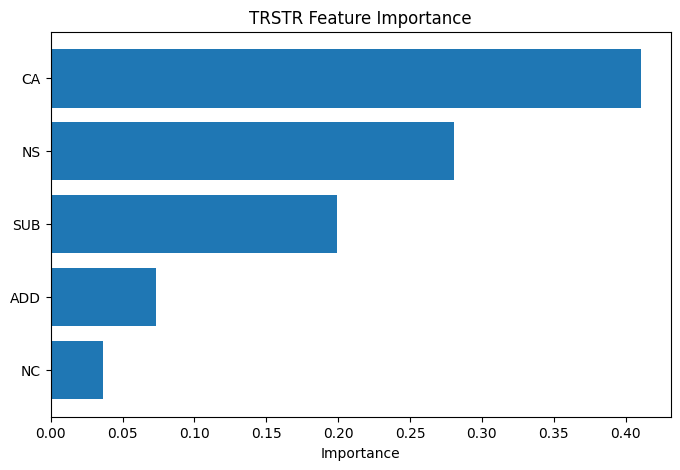

In [18]:
def extract_feature_importance(tree, feature_names):
    if hasattr(tree, "get_feature_importance"):
        imp = tree.get_feature_importance()
        return pd.DataFrame({"feature": list(imp.keys()), "importance": list(imp.values())})
    elif hasattr(tree, "feature_importances_"):
        return pd.DataFrame({"feature": feature_names, "importance": tree.feature_importances_})
    return pd.DataFrame(columns=["feature", "importance"])

importance_df = extract_feature_importance(trstr_model, DIAGNOSTIC_FEATURES)
if not importance_df.empty:
    importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)
    importance_path = MODEL_OUTPUTS_DIR / "trstr_feature_importance.csv"
    importance_df.to_csv(importance_path, index=False)
    print("Saved feature importance:", importance_path)
    display(importance_df)

    plt.figure(figsize=(8, 5))
    top = importance_df.head(15).iloc[::-1]
    plt.barh(top["feature"], top["importance"])
    plt.title("TRSTR Feature Importance")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Feature importance not available for this tree backend.")

## 16. Validator Criteria Checklist

Use this section as the notebook-level self-check before external validation.

In [19]:
checklist = pd.DataFrame([
    {
        "criterion": "A5 / F4 leakage control",
        "status": "Pass if reviewed",
        "evidence": "Split occurs before fitted preprocessing; medians/IQR limits are fitted only on train_raw; validation/test are transformed using train-fitted parameters.",
    },
    {
        "criterion": "B3 label-feature separation",
        "status": "Pass if label-source variable excluded",
        "evidence": "Only FUNA-DB task features are used as predictors; possible RMAT/reference columns are audited and excluded from DIAGNOSTIC_FEATURES.",
    },
    {
        "criterion": "D3 GAN training-only rule",
        "status": "Pass if RUN_GAN_GENERATION cell executed as written",
        "evidence": "GAN input is train_raw[Label == 1][RAW_FEATURES]; no validation or test rows are used.",
    },
    {
        "criterion": "E synthetic validation",
        "status": "Pass if dist_results support similarity",
        "evidence": "KS, JSD, and summary-statistic checks compare synthetic At-Risk rows against real At-Risk training rows only.",
    },
    {
        "criterion": "G metrics and interpretation",
        "status": "Pass if final comparison reported",
        "evidence": "Recall, precision, F1, F2, accuracy, AUC, RMSE, confusion matrix, and trade-off interpretation are reported.",
    },
    {
        "criterion": "H overall validity",
        "status": "Depends on final outputs",
        "evidence": "Pipeline is methodologically valid if leakage checks pass and final claims remain limited to proof-of-concept screening support.",
    },
])

display(checklist)
checklist_path = MODEL_OUTPUTS_DIR / "validator_checklist.csv"
checklist.to_csv(checklist_path, index=False)
print("Saved checklist:", checklist_path)

,criterion,status,evidence
0,A5 / F4 leakage control,Pass if reviewed,Split occurs before fitted preprocessing; medi...
1,B3 label-feature separation,Pass if label-source variable excluded,Only FUNA-DB task features are used as predict...
2,D3 GAN training-only rule,Pass if RUN_GAN_GENERATION cell executed as wr...,GAN input is train_raw[Label == 1][RAW_FEATURE...
3,E synthetic validation,Pass if dist_results support similarity,"KS, JSD, and summary-statistic checks compare ..."
4,G metrics and interpretation,Pass if final comparison reported,"Recall, precision, F1, F2, accuracy, AUC, RMSE..."
5,H overall validity,Depends on final outputs,Pipeline is methodologically valid if leakage ...


Saved checklist: /Users/kristofferneo/Documents/dyscalc-thesis/DysCalc-ML-Development/outputs/model_results/validator_checklist.csv


## 17. Final Notes for Repository README

Recommended README wording:

> The main reproducible ML validation pipeline is contained in `DysCalc_ML_Validation_Pipeline.ipynb`. This notebook performs splitting before fitted preprocessing, trains synthetic-data generators only on real At-Risk training samples, keeps validation/test sets fully real, and compares TRTR against TRSTR using recall, F2-score, precision, accuracy, AUC, RMSE, and confusion matrices. Earlier notebooks are retained as supporting exploratory or experimental notebooks.

Recommended repository organization:

```text
notebooks/
  DysCalc_ML_Validation_Pipeline.ipynb      # main validator notebook
  dataset_analysis.ipynb                    # supporting EDA
  synthetic_data_generation.ipynb           # legacy/supporting synthetic experiments
  tstr_vs_trtr_no_thresholding.ipynb        # previous model comparison
  tstr_vs_trtr.ipynb                        # thresholding experiment
```